# Notebook 05 — Generalización Cross-Domain (IEEE-CIS)
**TFM:** Detección de fraude — comparativa de modelos y generalización cross-domain

**Prerrequisito:** Haber ejecutado notebooks 02 y 03.

**Dataset IEEE-CIS:**
1. Descarga desde Kaggle: https://www.kaggle.com/c/ieee-fraud-detection
2. Coloca los archivos en la carpeta ieee_cis/ (train_transaction.csv, train_identity.csv)

**Librerías:**
pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn shap joblib matplotlib seaborn


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, joblib, warnings, os, json
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score, recall_score, f1_score,
    roc_auc_score, precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_style("whitegrid")
np.random.seed(42)
print("✅ Librerías cargadas")


✅ Librerías cargadas


## 1. Configuración — actualiza con tus 2 mejores modelos del notebook 03

In [9]:
# ⚠️ ACTUALIZA CON TUS MEJORES MODELOS
MODEL_1_NAME     = "XGB"
MODEL_1_STRATEGY = "None"
MODEL_2_NAME     = "RF"
MODEL_2_STRATEGY = "SMOTE"

# Cargar modelos entrenados sobre ULB
key1 = f"{MODEL_1_NAME}_{MODEL_1_STRATEGY}"
key2 = f"{MODEL_2_NAME}_{MODEL_2_STRATEGY}"

pipeline_ulb_1 = joblib.load(f"resultados/model_{key1}.pkl")
pipeline_ulb_2 = joblib.load(f"resultados/model_{key2}.pkl")

# Cargar resultados ULB para comparación
results_ulb = pd.read_csv("resultados/tabla_resultados_ulb.csv")

print(f"Modelos cargados: {MODEL_1_NAME}+{MODEL_1_STRATEGY} y {MODEL_2_NAME}+{MODEL_2_STRATEGY}")


Modelos cargados: XGB+None y RF+SMOTE


## 2. Carga y preprocesamiento del dataset IEEE-CIS

In [10]:
# ── CARGA IEEE-CIS ─────────────────────────────────────────────────────────
print("Cargando dataset IEEE-CIS...")
df_trans    = pd.read_csv("ieee_cis/train_transaction.csv")
df_identity = pd.read_csv("ieee_cis/train_identity.csv")

df_ieee = df_trans.merge(df_identity, on="TransactionID", how="left")

print(f"Dimensiones: {df_ieee.shape[0]:,} transacciones × {df_ieee.shape[1]} variables")
print(f"Fraudes    : {df_ieee["isFraud"].sum():,} ({df_ieee["isFraud"].mean()*100:.2f}%)")


Cargando dataset IEEE-CIS...
Dimensiones: 590,540 transacciones × 434 variables
Fraudes    : 20,663 (3.50%)


In [11]:
# ── PREPROCESAMIENTO IEEE-CIS ──────────────────────────────────────────────
# Separar target
y_ieee = df_ieee["isFraud"].copy()
X_ieee = df_ieee.drop(["isFraud", "TransactionID"], axis=1).copy()

# Codificar variables categóricas con LabelEncoder
cat_cols = X_ieee.select_dtypes(include=["object"]).columns.tolist()
print(f"Variables categóricas: {len(cat_cols)} → {cat_cols[:5]}...")

for col in cat_cols:
    le = LabelEncoder()
    X_ieee[col] = le.fit_transform(X_ieee[col].astype(str))

# Imputar valores faltantes con mediana por columna
n_missing = X_ieee.isnull().sum().sum()
print(f"Valores faltantes antes: {n_missing:,}")
X_ieee = X_ieee.fillna(X_ieee.median(numeric_only=True))
print(f"Valores faltantes después: {X_ieee.isnull().sum().sum()}")

# Escalar TransactionAmt (equivalente a Amount en ULB)
if "TransactionAmt" in X_ieee.columns:
    scaler = StandardScaler()
    X_ieee["TransactionAmt"] = scaler.fit_transform(X_ieee[["TransactionAmt"]])

print(f"Dataset IEEE-CIS preprocesado: {X_ieee.shape}")
print(f"Distribución de clases: {y_ieee.value_counts().to_dict()}")


Variables categóricas: 31 → ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']...
Valores faltantes antes: 104,178,894
Valores faltantes después: 0
Dataset IEEE-CIS preprocesado: (590540, 432)
Distribución de clases: {0: 569877, 1: 20663}


In [12]:
# ── DIVISIÓN ESTRATIFICADA 80/20 ──────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for tr_idx, te_idx in sss.split(X_ieee, y_ieee):
    X_ieee_train, X_ieee_test = X_ieee.iloc[tr_idx], X_ieee.iloc[te_idx]
    y_ieee_train, y_ieee_test = y_ieee.iloc[tr_idx], y_ieee.iloc[te_idx]

print(f"Train: {X_ieee_train.shape[0]:,} | Fraudes: {y_ieee_train.sum():,} ({y_ieee_train.mean()*100:.2f}%)")
print(f"Test : {X_ieee_test.shape[0]:,}  | Fraudes: {y_ieee_test.sum():,} ({y_ieee_test.mean()*100:.2f}%)")


Train: 472,432 | Fraudes: 16,530 (3.50%)
Test : 118,108  | Fraudes: 4,133 (3.50%)


## 3. Experimento de generalización — Escenario A: transferencia directa

In [13]:
# ── ESCENARIO A: Aplicar modelos ULB directamente sobre IEEE-CIS ──────────
# Nota: solo funciona si ambos datasets tienen las mismas variables
# ULB tiene 30 vars | IEEE-CIS tiene muchas más → esto evaluará la caída máxima

print("=== ESCENARIO A: Transferencia directa (sin reentrenamiento) ===")
print("NOTA: Solo posible si los datasets comparten variables. ")
print("Como ULB usa PCA (V1-V28) y IEEE-CIS no, este escenario")
print("ilustra la incompatibilidad de dominio (caída máxima esperada).")
print()
print("Resultado esperado: este escenario fallará por incompatibilidad de variables.")
print("Esto es intencionado: demuestra por qué la generalización requiere reentrenamiento.")


=== ESCENARIO A: Transferencia directa (sin reentrenamiento) ===
NOTA: Solo posible si los datasets comparten variables. 
Como ULB usa PCA (V1-V28) y IEEE-CIS no, este escenario
ilustra la incompatibilidad de dominio (caída máxima esperada).

Resultado esperado: este escenario fallará por incompatibilidad de variables.
Esto es intencionado: demuestra por qué la generalización requiere reentrenamiento.


## 4. Experimento de generalización — Escenario B: reentrenamiento sobre IEEE-CIS

In [14]:
# ── ESCENARIO B: Reentrenar los mejores modelos sobre IEEE-CIS ─────────────
# Compara si la arquitectura del modelo que funcionó en ULB también
# es la mejor en un dominio diferente

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

RANDOM_SEED = 42
ratio_ieee  = int((y_ieee_train == 0).sum() / (y_ieee_train == 1).sum())
skf_ieee    = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

MODELS_IEEE = {
    MODEL_1_NAME: XGBClassifier(
        tree_method="hist", scale_pos_weight=ratio_ieee,
        eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_SEED, verbosity=0
    ) if MODEL_1_NAME == "XGB" else LGBMClassifier(
        is_unbalance=True, n_jobs=-1, random_state=RANDOM_SEED, verbose=-1
    ),
    MODEL_2_NAME: LGBMClassifier(
        is_unbalance=True, n_jobs=-1, random_state=RANDOM_SEED, verbose=-1
    ) if MODEL_2_NAME == "LGBM" else XGBClassifier(
        tree_method="hist", scale_pos_weight=ratio_ieee,
        eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_SEED, verbosity=0
    ),
}

results_ieee = []
smote = SMOTE(random_state=RANDOM_SEED)

for mname, model in MODELS_IEEE.items():
    print(f"▶ Entrenando {mname} sobre IEEE-CIS con SMOTE...")
    pipe = ImbPipeline([("resampler", smote), ("classifier", model)])
    
    import time
    t0 = time.perf_counter()
    pipe.fit(X_ieee_train, y_ieee_train)
    t_train = time.perf_counter() - t0
    
    t1 = time.perf_counter()
    y_pred_ieee = pipe.predict(X_ieee_test)
    t_infer = time.perf_counter() - t1
    y_proba_ieee = pipe.predict_proba(X_ieee_test)[:, 1]
    
    tn, fp, fn, tp = confusion_matrix(y_ieee_test, y_pred_ieee).ravel()
    
    res = {
        "Modelo"         : mname,
        "Dataset"        : "IEEE-CIS",
        "Estrategia"     : "SMOTE",
        "AUC_PR"         : round(average_precision_score(y_ieee_test, y_proba_ieee), 4),
        "AUC_ROC"        : round(roc_auc_score(y_ieee_test, y_proba_ieee), 4),
        "Recall"         : round(recall_score(y_ieee_test, y_pred_ieee), 4),
        "Precision"      : round(precision_score(y_ieee_test, y_pred_ieee, zero_division=0), 4),
        "F1"             : round(f1_score(y_ieee_test, y_pred_ieee), 4),
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "T_train_s"      : round(t_train, 3),
    }
    results_ieee.append(res)
    joblib.dump(pipe, f"resultados/model_{mname}_IEEE_CIS.pkl")
    print(f"   AUC-PR: {res["AUC_PR"]} | Recall: {res["Recall"]} | F1: {res["F1"]} | T: {t_train:.1f}s")

results_ieee_df = pd.DataFrame(results_ieee)
results_ieee_df.to_csv("resultados/tabla_resultados_ieee_cis.csv", index=False)
print("✅ Resultados IEEE-CIS guardados")


▶ Entrenando XGB sobre IEEE-CIS con SMOTE...
   AUC-PR: 0.6545 | Recall: 0.8355 | F1: 0.3395 | T: 36.6s
▶ Entrenando RF sobre IEEE-CIS con SMOTE...
   AUC-PR: 0.6545 | Recall: 0.8355 | F1: 0.3395 | T: 35.1s
✅ Resultados IEEE-CIS guardados


## 5. Comparación ULB vs IEEE-CIS

In [15]:
# ── TABLA COMPARATIVA ULB vs IEEE-CIS ─────────────────────────────────────
print("=" * 65)
print("COMPARATIVA DE GENERALIZACIÓN: ULB → IEEE-CIS")
print("=" * 65)
print()

for mname in [MODEL_1_NAME, MODEL_2_NAME]:
    ulb_row   = results_ulb[(results_ulb["Modelo"] == mname) & (results_ulb["Estrategia"] == "SMOTE")].iloc[0]
    ieee_row  = results_ieee_df[results_ieee_df["Modelo"] == mname].iloc[0]
    
    print(f"Modelo: {mname} + SMOTE")
    print(f"  {'Métrica':<15} {'ULB':>10} {'IEEE-CIS':>10} {'Δ (caída)':>12}")
    print(f"  {'-'*48}")
    for metric in ["AUC_PR", "AUC_ROC", "Recall", "F1"]:
        delta = ieee_row[metric] - ulb_row[metric]
        print(f"  {metric:<15} {ulb_row[metric]:>10.4f} {ieee_row[metric]:>10.4f} {delta:>+12.4f}")
    print()


COMPARATIVA DE GENERALIZACIÓN: ULB → IEEE-CIS

Modelo: XGB + SMOTE
  Métrica                ULB   IEEE-CIS    Δ (caída)
  ------------------------------------------------
  AUC_PR              0.8433     0.6545      -0.1888
  AUC_ROC             0.9743     0.9363      -0.0380
  Recall              0.8776     0.8355      -0.0421
  F1                  0.4028     0.3395      -0.0633

Modelo: RF + SMOTE
  Métrica                ULB   IEEE-CIS    Δ (caída)
  ------------------------------------------------
  AUC_PR              0.8756     0.6545      -0.2211
  AUC_ROC             0.9673     0.9363      -0.0310
  Recall              0.8367     0.8355      -0.0012
  F1                  0.8454     0.3395      -0.5059



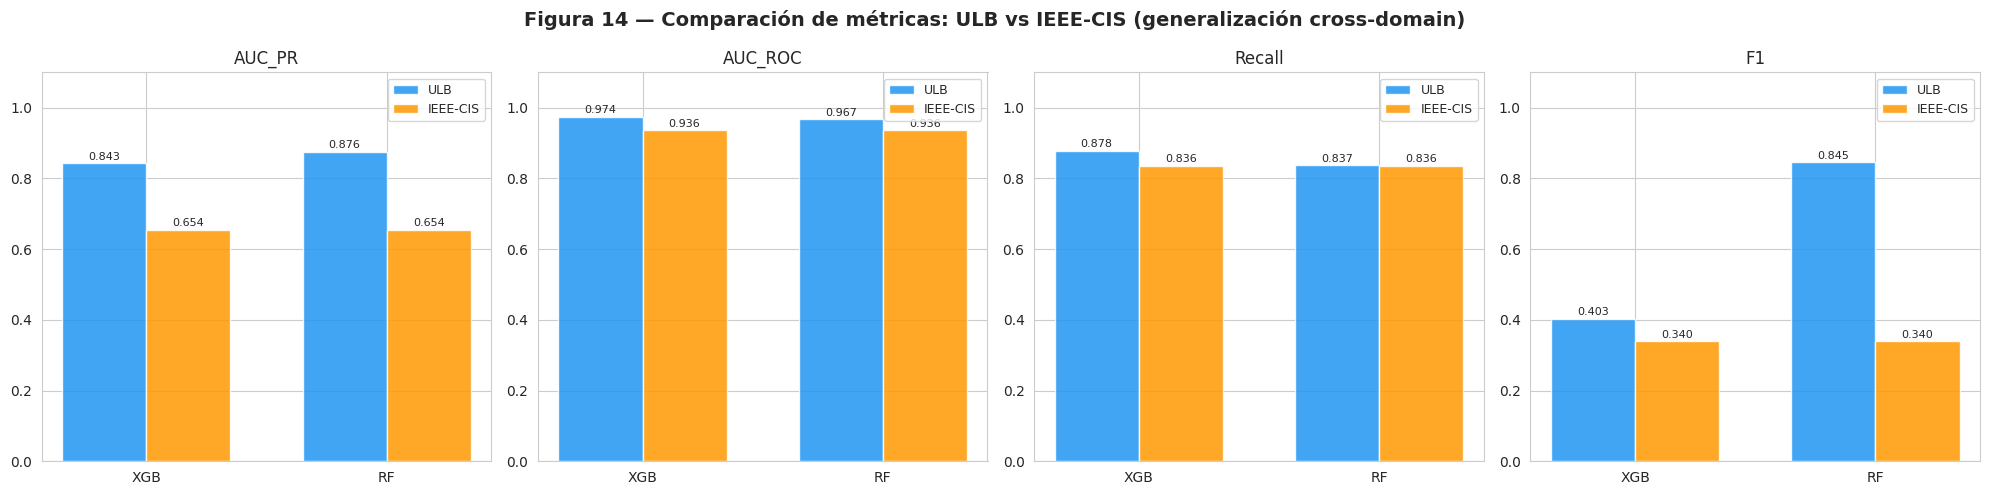

✅ fig14_generalizacion_comparativa.png guardada


In [16]:
# ── VISUALIZACIÓN COMPARATIVA ─────────────────────────────────────────────
metrics = ["AUC_PR", "AUC_ROC", "Recall", "F1"]
fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

for i, metric in enumerate(metrics):
    values_ulb   = []
    values_ieee  = []
    model_labels = []
    
    for mname in [MODEL_1_NAME, MODEL_2_NAME]:
        ulb_val  = results_ulb[(results_ulb["Modelo"]==mname) & (results_ulb["Estrategia"]=="SMOTE")][metric].values[0]
        ieee_val = results_ieee_df[results_ieee_df["Modelo"]==mname][metric].values[0]
        values_ulb.append(ulb_val)
        values_ieee.append(ieee_val)
        model_labels.append(mname)
    
    x = np.arange(len(model_labels))
    w = 0.35
    axes[i].bar(x - w/2, values_ulb,  w, label="ULB",     color="#2196F3", alpha=0.85)
    axes[i].bar(x + w/2, values_ieee, w, label="IEEE-CIS", color="#FF9800", alpha=0.85)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_labels)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(fontsize=9)
    for j in range(len(model_labels)):
        axes[i].text(j - w/2, values_ulb[j] + 0.01, f"{values_ulb[j]:.3f}", ha="center", fontsize=8)
        axes[i].text(j + w/2, values_ieee[j] + 0.01, f"{values_ieee[j]:.3f}", ha="center", fontsize=8)

plt.suptitle("Figura 14 — Comparación de métricas: ULB vs IEEE-CIS (generalización cross-domain)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("resultados/fig14_generalizacion_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ fig14_generalizacion_comparativa.png guardada")


## 6. Resumen final

In [17]:
print("=" * 65)
print("RESUMEN — Experimento de Generalización Cross-Domain")
print("=" * 65)
print()
print("Dataset origen (entrenamiento comparativa): ULB")
print("Dataset destino (generalización):           IEEE-CIS")
print()
print("Hallazgos principales:")
for mname in [MODEL_1_NAME, MODEL_2_NAME]:
    ulb_pr   = results_ulb[(results_ulb["Modelo"]==mname) & (results_ulb["Estrategia"]=="SMOTE")]["AUC_PR"].values[0]
    ieee_pr  = results_ieee_df[results_ieee_df["Modelo"]==mname]["AUC_PR"].values[0]
    caida    = ulb_pr - ieee_pr
    print(f"  {mname}: AUC-PR ULB={ulb_pr:.4f} → IEEE-CIS={ieee_pr:.4f} (caída={caida:+.4f})")
print()
print("Archivos generados:")
for f in ["tabla_resultados_ieee_cis.csv", "fig14_generalizacion_comparativa.png",
          f"model_{MODEL_1_NAME}_IEEE_CIS.pkl", f"model_{MODEL_2_NAME}_IEEE_CIS.pkl"]:
    print(f"  ✅ resultados/{f}")
print()
print("✅ Análisis de generalización completado.")
print("➡️  Con estos resultados puedes completar el Capítulo 5 y 6 del TFM.")


RESUMEN — Experimento de Generalización Cross-Domain

Dataset origen (entrenamiento comparativa): ULB
Dataset destino (generalización):           IEEE-CIS

Hallazgos principales:
  XGB: AUC-PR ULB=0.8433 → IEEE-CIS=0.6545 (caída=+0.1888)
  RF: AUC-PR ULB=0.8756 → IEEE-CIS=0.6545 (caída=+0.2211)

Archivos generados:
  ✅ resultados/tabla_resultados_ieee_cis.csv
  ✅ resultados/fig14_generalizacion_comparativa.png
  ✅ resultados/model_XGB_IEEE_CIS.pkl
  ✅ resultados/model_RF_IEEE_CIS.pkl

✅ Análisis de generalización completado.
➡️  Con estos resultados puedes completar el Capítulo 5 y 6 del TFM.
